In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/Products.csv
/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/stores.csv
/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/Customers.csv
/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/sales_transactions.csv


In [2]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/sales_transactions.csv')

products = pd.read_csv('/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/Products.csv')

stores = pd.read_csv('/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/stores.csv')

customers = pd.read_csv('/kaggle/input/datasets/umangsinghgangash06/festive-campaign-analysis-sales-data/Customers.csv')

In [3]:
print("Sales Shape:", sales.shape)
print("Products Shape:", products.shape)
print("Stores Shape:", stores.shape)
print("Customers Shape:", customers.shape)

Sales Shape: (10000, 11)
Products Shape: (1000, 5)
Stores Shape: (500, 5)
Customers Shape: (10000, 4)


In [4]:
print(sales.columns.tolist())
print(products.columns.tolist())
print(stores.columns.tolist())
print(customers.columns.tolist())

['S.No.', 'Transaction_ID', 'Date', 'Store_ID', 'Customer_id', 'Product_ID', 'Quantity', 'Revenue', 'Discount', 'Festival Name', 'Payment Mode']
['Product_ID', 'Product_Name', 'Category', 'Brand', 'Price']
['Store_ID', 'City', 'State', 'Region', 'Store_Type']
['Customer_ID', 'Age_group', 'Gender', 'Loyality_Status']


In [5]:
customers.rename(columns={
    'Customer_ID':'Customer_id',
    'Age_group ': ' Age_Group',
    'Loyality_Status':'Loyalty_Status'
}, inplace=True)

sales.rename(columns={
    'Festival Name':'Festival_Name',
    'Payment Mode':'Payment_Mode'
}, inplace=True)

In [6]:
print(customers.columns)
print(sales.columns)

Index(['Customer_id', 'Age_group', 'Gender', 'Loyalty_Status'], dtype='object')
Index(['S.No.', 'Transaction_ID', 'Date', 'Store_ID', 'Customer_id',
       'Product_ID', 'Quantity', 'Revenue', 'Discount', 'Festival_Name',
       'Payment_Mode'],
      dtype='object')


In [7]:
df = sales.merge(products,on='Product_ID')
df = df.merge(stores,on='Store_ID')
df = df.merge(customers,on='Customer_id')

print(df.shape)
df.head()

(10000, 22)


,S.No.,Transaction_ID,Date,Store_ID,Customer_id,Product_ID,Quantity,Revenue,Discount,Festival_Name,...,Category,Brand,Price,City,State,Region,Store_Type,Age_group,Gender,Loyalty_Status
0,1,TXN000001,10-04-2025,ST292,CU04014,PR0586,2,8352,50,Holi,...,Decoration,Philips,1949,Delhi,Delhi,North,Hypermarket,26-35,Male,Gold
1,2,TXN000002,18-03-2025,ST114,CU05899,PR0955,10,8032,37,Holi,...,Home Appliances,Samsung,7635,Jaipur,Rajasthan,North,Local Retail,60+,Male,Bronze
2,3,TXN000003,23-03-2025,ST287,CU04904,PR0787,10,16547,13,Diwali,...,Decoration,Sony,2817,Hyderabad,Telangana,South,Local Retail,60+,Male,Silver
3,4,TXN000004,22-09-2025,ST101,CU03704,PR0758,4,3623,18,Sankranti,...,Home Appliances,Nike,30864,Lucknow,Uttar Pradesh,North,Local Retail,46-60,Female,Bronze
4,5,TXN000005,01-10-2025,ST072,CU09023,PR0491,3,2446,36,Holi,...,Grocery,Nike,2064,Lucknow,Uttar Pradesh,North,Hypermarket,60+,Female,Bronze


In [8]:
kpi = pd.DataFrame({
    'Metric':[
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Average Order Value'
    ],
    'Value':[
        df['Revenue'].sum(),
        df['Transaction_ID'].nunique(),
        df['Customer_id'].nunique(),
        round(
            df['Revenue'].sum() /
            df['Transaction_ID'].nunique(),
            2
        )
    ]
})

print(kpi)

                Metric        Value
0        Total Revenue  75532294.00
1         Total Orders     10000.00
2      Total Customers      6308.00
3  Average Order Value      7553.23


In [9]:
festival_analysis = (
    df.groupby('Festival_Name')
      .agg(
        Revenue=('Revenue','sum'),
        Orders=('Transaction_ID','count')
      )
      .sort_values(
          'Revenue',
          ascending=False
      )
)

festival_analysis

,Revenue,Orders
Festival_Name,,
Diwali,31520366,2529
Sankranti,22615440,2507
Holi,15110205,2481
Normal Day,6286283,2483


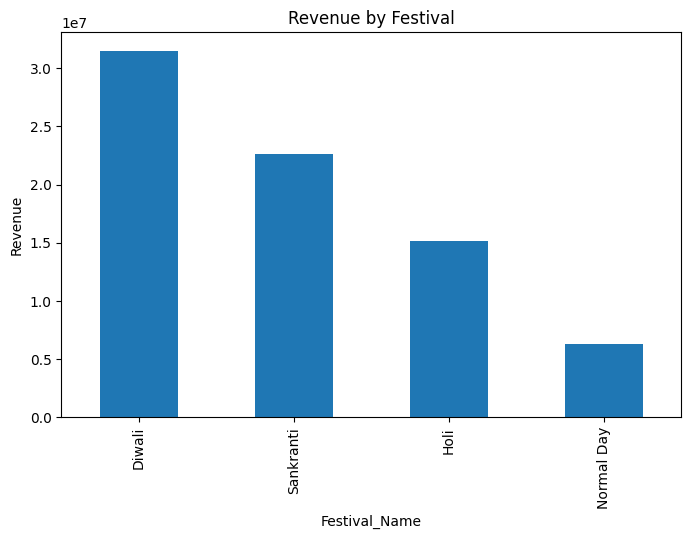

In [10]:
import matplotlib.pyplot as plt

festival_analysis['Revenue'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Revenue by Festival'
)

plt.ylabel('Revenue')
plt.show()

In [11]:
top_products = (
    df.groupby('Product_Name')
      ['Revenue']
      .sum()
      .sort_values(
          ascending=False
      )
      .head(10)
)

top_products

Product_Name
Microwave            9217125
Saree                8123358
T-Shirt              7997134
Smart TV             7532325
Mixer Grinder        7314342
LED Lights           7309020
Laptop               7167103
Rice Bag             7151441
Bluetooth Speaker    6897032
Refrigerator         6823414
Name: Revenue, dtype: int64

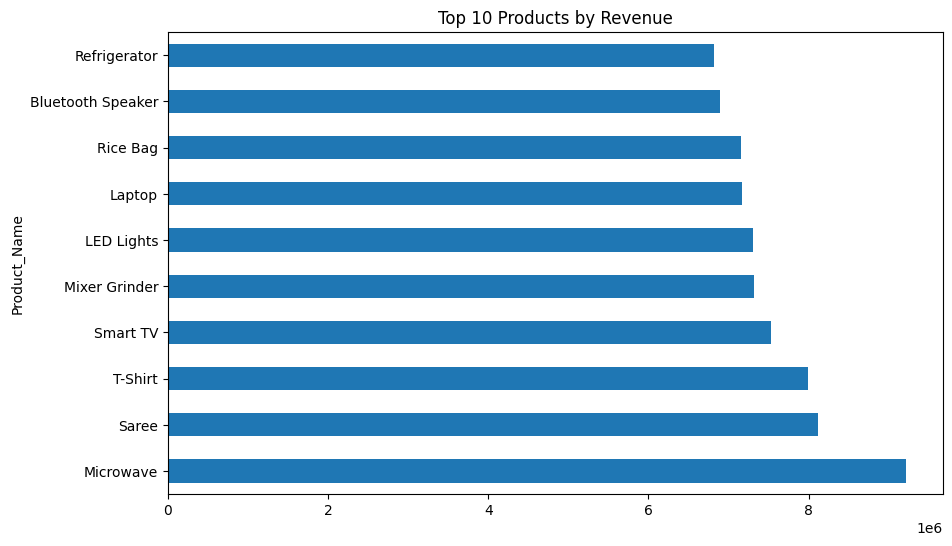

In [12]:
top_products.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title(
    'Top 10 Products by Revenue'
)

plt.show()

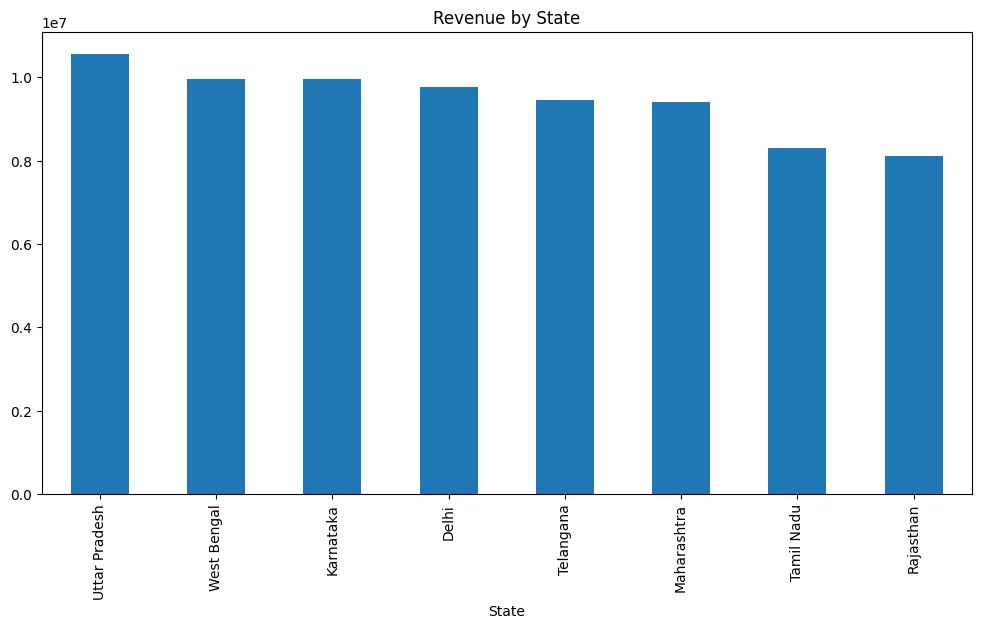

In [13]:
state_analysis = (
    df.groupby('State')
      ['Revenue']
      .sum()
      .sort_values(
          ascending=False
      )
)

state_analysis

state_analysis.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Revenue by State'
)

plt.show()


In [14]:
gender_analysis = (
    df.groupby('Gender')
      ['Revenue']
      .sum()
)

gender_analysis

Gender
Female    38322888
Male      37209406
Name: Revenue, dtype: int64

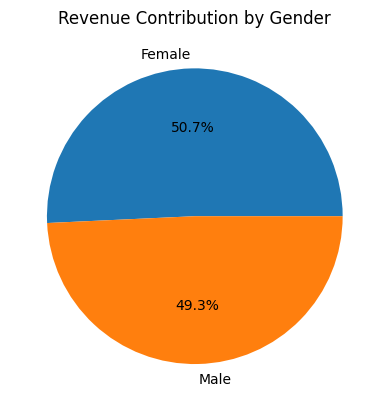

In [15]:
gender_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title(
    'Revenue Contribution by Gender'
)

plt.show()

In [16]:
loyalty_analysis = (
    df.groupby('Loyalty_Status')
      ['Revenue']
      .sum()
      .sort_values(
          ascending=False
      )
)

loyalty_analysis

Loyalty_Status
Gold          19305584
Bronze        19251101
Non-Member    19223179
Silver        17752430
Name: Revenue, dtype: int64

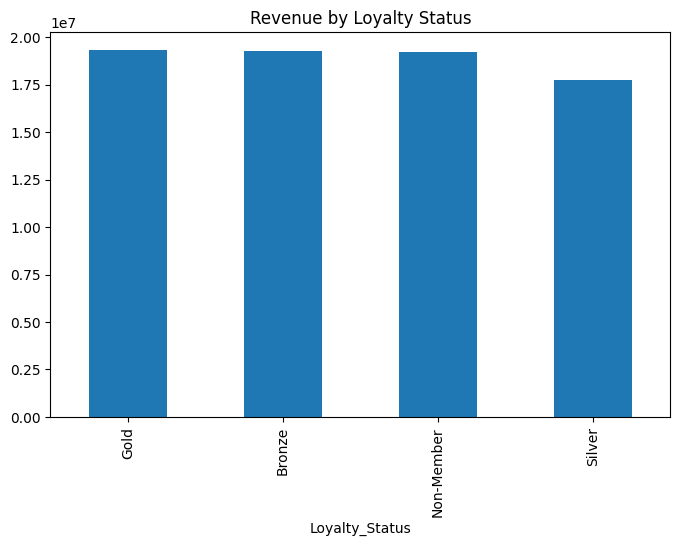

In [17]:
loyalty_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Revenue by Loyalty Status'
)

plt.show()

In [18]:
category_analysis = (
    df.groupby('Category')
      ['Revenue']
      .sum()
      .sort_values(
          ascending=False
      )
)

category_analysis

Category
Home Appliances    23354881
Electronics        21596460
Clothing           16120492
Decoration          7309020
Grocery             7151441
Name: Revenue, dtype: int64

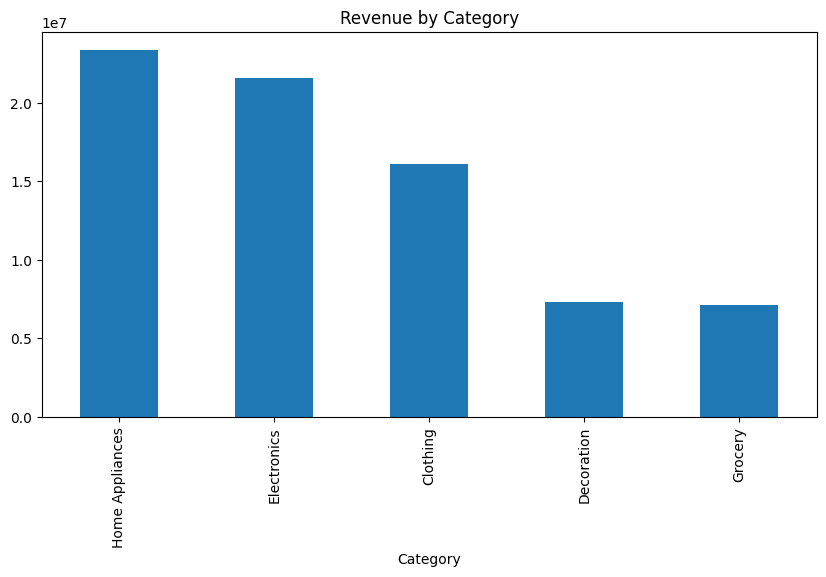

In [19]:
category_analysis.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Revenue by Category'
)

plt.show()

In [20]:
payment_analysis = (
    df.groupby('Payment_Mode')
      ['Revenue']
      .sum()
)

payment_analysis

Payment_Mode
Card    25156369
Cash    25319653
UPI     25056272
Name: Revenue, dtype: int64

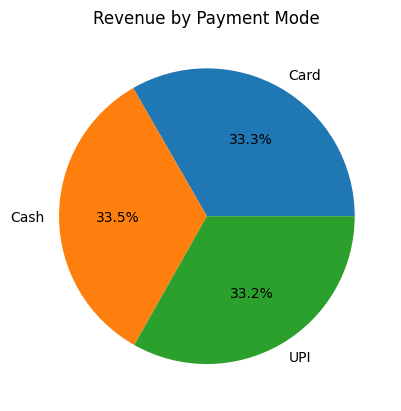

In [21]:
payment_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title(
    'Revenue by Payment Mode'
)

plt.show()

In [22]:
print(
    "Highest Revenue Festival:",
    festival_analysis['Revenue'].idxmax()
)

print(
    "Top State:",
    state_analysis.idxmax()
)

print(
    "Top Product:",
    top_products.idxmax()
)

print(
    "Best Category:",
    category_analysis.idxmax()
)

print(
    "Preferred Payment Mode:",
    payment_analysis.idxmax()
)

Highest Revenue Festival: Diwali
Top State: Uttar Pradesh
Top Product: Microwave
Best Category: Home Appliances
Preferred Payment Mode: Cash
